In [2]:
import zarr 
import numpy as np

In [3]:
PATH = "/home/naren-root/Documents/FYP2/data/madurai_complete.zarr"


In [16]:
f = zarr.open_group(PATH)

In [24]:
for i in f["products"]["sentinel2"].keys():
    print(i)

labels
valid
data
band_names


In [17]:
f["products"]["sentinel2"]["data"]

<Array file:///home/naren-root/Documents/FYP2/data/madurai_complete.zarr/products/sentinel2/data shape=(132, 17, 2438, 2621) dtype=float32>

In [31]:
for i in range(132):
    print(f["products"]["sentinel2"]["data"][i , : , 500, 500])

[nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan]
[nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan]
[nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan]
[nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan]
[nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan]
[nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan]
[nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan]
[nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan]
[-inf -inf -inf -inf -inf -inf -inf -inf -inf -inf -inf -inf -inf -inf
 -inf -inf -inf]
[nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan]
[-inf -inf -inf -inf -inf -inf -inf -inf -inf -inf -inf -inf -inf -inf
 -inf -inf -inf]
[-inf -inf -inf -inf -inf -inf -inf -inf -inf -inf -inf -inf -inf -inf
 -inf -inf -inf]
[-inf -inf -inf -inf -inf -inf -inf -inf -inf -inf -inf -inf -inf -inf
 -inf -inf -inf]
[-inf -inf -inf -i

In [4]:
import zarr
import xarray as xr
import dask.array as da

# 1. Open the Zarr group "raw" (this does not load data into RAM)
root = zarr.open(PATH, mode='r')
s2_data = root["products/sentinel2/data"]

# 2. Convert the raw Zarr array into a Dask array
# This is the "shield" that prevents the 53GB MemoryError
dask_array = da.from_zarr(s2_data)

# 3. Wrap it in Xarray and manually define the dimensions
# Based on your Sentinel-2 shape, the order is usually:
# (Time, Band, Y, X)
ds = xr.DataArray(
    dask_array,
    dims=["time", "band", "y", "x"],
    name="sentinel2"
).to_dataset()

# This just sets up the plan
temporal_median = ds["sentinel2"].median(dim="time")

# This actually runs the math


In [5]:
temporal_median

<xarray.DataArray 'sentinel2' (band: 17, y: 2438, x: 2621)> Size: 435MB
dask.array<nanmedian, shape=(17, 2438, 2621), dtype=float32, chunksize=(16, 125, 125), chunktype=numpy.ndarray>
Dimensions without coordinates: band, y, x

In [15]:
ds['sentinel2'][0,0, 500, 500]

<xarray.DataArray 'sentinel2' ()> Size: 4B
dask.array<getitem, shape=(), dtype=float32, chunksize=(), chunktype=numpy.ndarray>

In [32]:
from helper import utils

# lazy access (no big load until you slice)
res = utils.load_all_data()



In [58]:
res['sentinel2']['data'][10, :, 1400, 1400]

array([ 0.62466604,  0.6218898 ,  0.40230492,  0.38252628, -0.4991403 ,
        0.19561777,  0.19561777, -0.3363655 , -0.19561777,  0.48877445,
       -0.19522116,  4.5818076 ,  0.14479999,  0.        ,  0.        ,
        3.        ,  3.        ], dtype=float32)

In [64]:
# audit_one_s2_tif.py
import numpy as np
import rasterio as rio
from pathlib import Path

p = Path("/home/naren-root/Documents/FYP2/data/highreslst_s2_local/processed_monthly/2021_04/tiles/S2_PROC_2021_04_Madurai_t0_1.tif")  # change this
with rio.open(p) as ds:
    arr = ds.read().astype(np.float32)  # (C,H,W)
    print("path:", p)
    print("shape:", arr.shape)
    print("dtype:", ds.dtypes)
    print("nodata:", ds.nodata)
    print("finite %:", np.isfinite(arr).mean() * 100)
    print("min/max (finite):", np.nanmin(np.where(np.isfinite(arr), arr, np.nan)),
          np.nanmax(np.where(np.isfinite(arr), arr, np.nan)))
    print("zero %:", (arr == 0).mean() * 100)

    # per-band quick scan
    for i in range(arr.shape[0]):
        a = arr[i]
        finite = np.isfinite(a)
        print(f"band{i+1:02d}: finite%={finite.mean()*100:6.2f}  "
              f"zero%={(a==0).mean()*100:6.2f}  "
              f"min/max={np.nanmin(np.where(finite,a,np.nan)):.4g}/{np.nanmax(np.where(finite,a,np.nan)):.4g}")


path: /home/naren-root/Documents/FYP2/data/highreslst_s2_local/processed_monthly/2021_04/tiles/S2_PROC_2021_04_Madurai_t0_1.tif
shape: (17, 346, 532)
dtype: ('float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32')
nodata: -inf
finite %: 50.07605719501065
min/max (finite): -2716.3955 1366.0074
zero %: 2.8377322940128287
band01: finite%= 50.08  zero%=  0.00  min/max=-0.02517/0.6239
band02: finite%= 50.08  zero%=  0.00  min/max=-0.01891/0.7508
band03: finite%= 50.08  zero%=  0.00  min/max=-0.01125/0.4506
band04: finite%= 50.08  zero%=  0.00  min/max=-0.008786/0.4415
band05: finite%= 50.08  zero%=  0.00  min/max=-0.5057/0.1182
band06: finite%= 50.08  zero%=  0.01  min/max=-0.3669/0.3955
band07: finite%= 50.08  zero%=  0.01  min/max=-0.3669/0.3955
band08: finite%= 50.08  zero%=  0.00  min/max=-0.4979/0.3707
band09: finite%= 50.08  zero%=  0.01  min/max=-0.3955/0

In [65]:
# audit_one_s2_tif.py
import numpy as np
import rasterio as rio
from pathlib import Path

p = Path("/home/naren-root/Documents/FYP2/data/sentinel2/S2_PROC_2021_04_Madurai.tif")  # change this
with rio.open(p) as ds:
    arr = ds.read().astype(np.float32)  # (C,H,W)
    print("path:", p)
    print("shape:", arr.shape)
    print("dtype:", ds.dtypes)
    print("nodata:", ds.nodata)
    print("finite %:", np.isfinite(arr).mean() * 100)
    print("min/max (finite):", np.nanmin(np.where(np.isfinite(arr), arr, np.nan)),
          np.nanmax(np.where(np.isfinite(arr), arr, np.nan)))
    print("zero %:", (arr == 0).mean() * 100)

    # per-band quick scan
    for i in range(arr.shape[0]):
        a = arr[i]
        finite = np.isfinite(a)
        print(f"band{i+1:02d}: finite%={finite.mean()*100:6.2f}  "
              f"zero%={(a==0).mean()*100:6.2f}  "
              f"min/max={np.nanmin(np.where(finite,a,np.nan)):.4g}/{np.nanmax(np.where(finite,a,np.nan)):.4g}")


path: /home/naren-root/Documents/FYP2/data/sentinel2/S2_PROC_2021_04_Madurai.tif
shape: (17, 2438, 2621)
dtype: ('float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32')
nodata: -inf
finite %: 50.293098683285976
min/max (finite): -4965.4033 10968.442
zero %: 3.1878643872538817
band01: finite%= 50.29  zero%=  0.00  min/max=-0.1806/0.6773
band02: finite%= 50.29  zero%=  0.00  min/max=-0.1476/0.8634
band03: finite%= 50.29  zero%=  0.00  min/max=-0.1154/0.5218
band04: finite%= 50.29  zero%=  0.00  min/max=-0.09572/0.526
band05: finite%= 50.29  zero%=  0.00  min/max=-0.5732/0.2258
band06: finite%= 50.29  zero%=  0.01  min/max=-0.5294/0.5388
band07: finite%= 50.29  zero%=  0.01  min/max=-0.5294/0.5388
band08: finite%= 50.29  zero%=  0.00  min/max=-0.6924/0.5227
band09: finite%= 50.29  zero%=  0.01  min/max=-0.5388/0.5294
band10: finite%= 50.29  zero%=  0.00  min/m

In [66]:
IDX_BANDS = ["NDVI","EVI","SAVI","MSAVI",
             "NDWI_water","NDWI_moisture","NDMI","MNDWI",
             "NDBI","UI","BSI","IBI","ALBEDO_proxy"]


In [67]:
len(IDX_BANDS)

13

In [1]:
import os, re, math
from pathlib import Path
import numpy as np
import rasterio
import matplotlib.pyplot as plt

VIIRS_DIR = Path("/home/naren-root/Documents/FYP2/data/viirs_dn")  # change if needed
PAT = re.compile(r"viirs_dn_(\d{4})_(\d{2})_(\d{2})\.tif$")

files = sorted([p for p in VIIRS_DIR.glob("viirs_dn_*.tif") if PAT.search(p.name)])
print("files:", len(files), "first:", files[0].name if files else None, "last:", files[-1].name if files else None)

def band_stats(arr):
    # arr is 2D float
    finite = np.isfinite(arr)
    if finite.sum() == 0:
        return dict(finite_frac=0.0, min=np.nan, max=np.nan, mean=np.nan, std=np.nan)
    v = arr[finite]
    return dict(
        finite_frac=float(finite.mean()),
        min=float(np.nanmin(v)),
        max=float(np.nanmax(v)),
        mean=float(np.nanmean(v)),
        std=float(np.nanstd(v)),
    )

rows = []
bad_files = []

for p in files:
    try:
        with rasterio.open(p) as ds:
            if ds.count != 2:
                bad_files.append((p.name, f"bands={ds.count}"))
                continue
            # Read bands as float32
            day = ds.read(1).astype(np.float32)
            night = ds.read(2).astype(np.float32)

            # Convert common fill to NaN if present (EE masked pixels often become nodata; still safe)
            day[~np.isfinite(day)] = np.nan
            night[~np.isfinite(night)] = np.nan

            sday = band_stats(day)
            snit = band_stats(night)

            rows.append({
                "file": p.name,
                "day_finite_frac": sday["finite_frac"],
                "day_mean": sday["mean"],
                "day_min": sday["min"],
                "day_max": sday["max"],
                "night_finite_frac": snit["finite_frac"],
                "night_mean": snit["mean"],
                "night_min": snit["min"],
                "night_max": snit["max"],
                "shape": (ds.height, ds.width),
                "crs": ds.crs.to_string() if ds.crs else None,
                "transform_a": float(ds.transform.a),
                "transform_e": float(ds.transform.e),
            })
    except Exception as e:
        bad_files.append((p.name, repr(e)))

print("parsed:", len(rows), "bad:", len(bad_files))
if bad_files[:10]:
    print("bad examples:", bad_files[:10])


files: 803 first: viirs_dn_2015_01_01.tif last: viirs_dn_2025_12_28.tif
parsed: 803 bad: 0


In [10]:
a, b = 0, 0
c = 0
for i in rows:
    a += i['day_mean']
    b += i['day_max']
    c += i['day_min']

a/809 + 273.15, b/809 , c/809 + 273.15

(nan, nan, nan)

files: 803 first: viirs_dn_2015_01_01.tif last: viirs_dn_2025_12_28.tif
parsed: 803 bad: 0

Unique grids (shape, px, py, crs):
      shape      px      py         crs
0  (49, 53)  1000.0  1000.0  EPSG:32644

Day valid fraction:
  mean   : 0.1560431569814682
  median : 0.0412013866007328
  p05/p95: 0.0 0.5217558741569519
  min/max: 0.0 0.5217558741569519

Night valid fraction:
  mean   : 0.21092207729816437
  median : 0.08971890807151794
  p05/p95: 0.0 0.5217558741569519
  min/max: 0.0 0.5217558741569519

Either(day|night) valid fraction:
  mean   : 0.30748143792152405
  median : 0.3465537130832672
  p05/p95: 0.008471312932670116 0.5217558741569519
  min/max: 0.0003850596840493381 0.5217558741569519

Counts:
  files with day_valid_frac==0   : 313
  files with night_valid_frac==0 : 310
  files with both zero           : 0


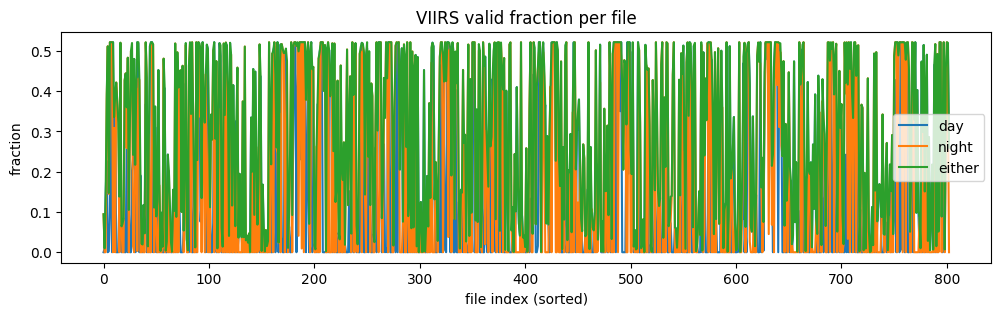

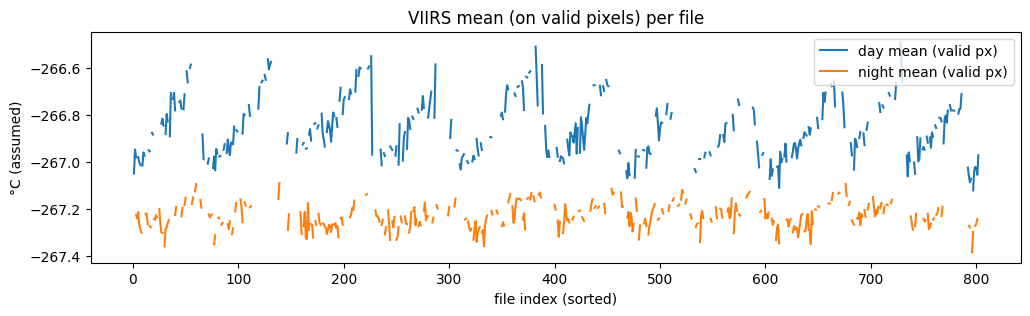


Example files:
  best : viirs_dn_2015_01_10.tif
  med  : viirs_dn_2016_01_15.tif
  worst: viirs_dn_2018_09_05.tif


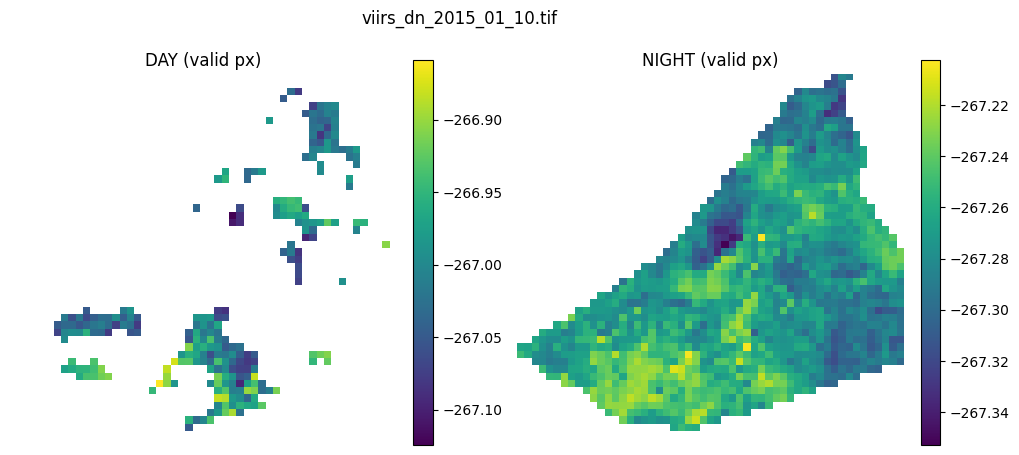

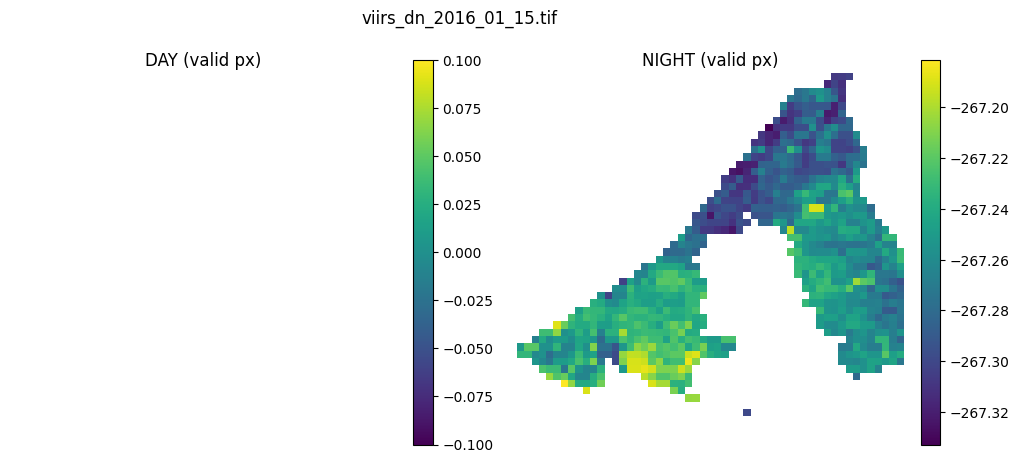

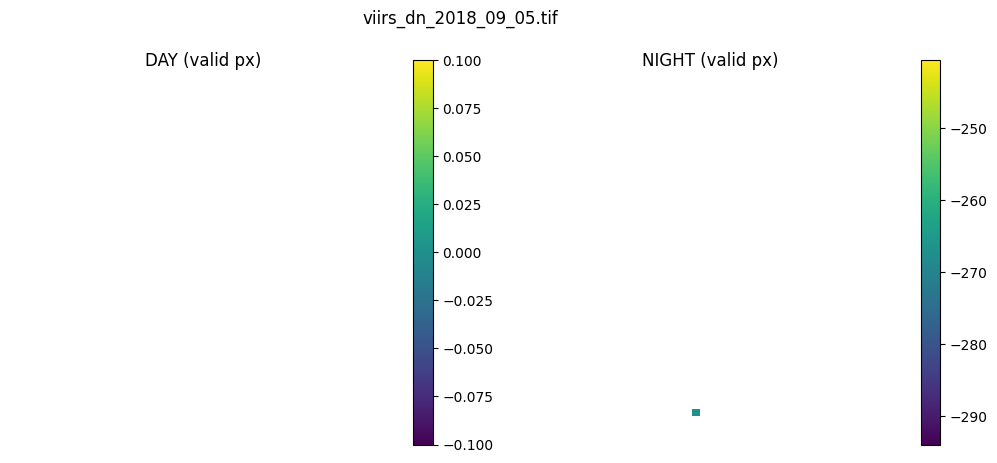


Saved: /home/naren-root/Documents/FYP2/data/viirs_dn/viirs_dn_quality_report.csv


In [11]:
# VIIRS DN GeoTIFF quality report
# - Counts valid pixels robustly (handles nodata, -inf/inf, and common fill values)
# - Reports per-file valid fractions for Day/Night, plus summary stats and plots
# - Optionally applies a "plausible Celsius range" filter to catch unit/garbage issues

import re
from pathlib import Path
import numpy as np
import rasterio
import matplotlib.pyplot as plt
import pandas as pd

VIIRS_DIR = Path("/home/naren-root/Documents/FYP2/data/viirs_dn")  # change if needed
PAT = re.compile(r"viirs_dn_(\d{4})_(\d{2})_(\d{2})\.tif$")

# ---- Configure nodata / validity rules ----
# These do NOT change values; they only define what is "valid" for QC.
FILL_VALUE_CANDIDATES = [-9999.0, -9998.0, 0.0]  # keep 0.0 only if you KNOW 0 means fill for your export
USE_PLAUSIBLE_RANGE = False
PLAUSIBLE_MIN_C = -300.0
PLAUSIBLE_MAX_C = 300.0

files = sorted([p for p in VIIRS_DIR.glob("viirs_dn_*.tif") if PAT.search(p.name)])
print("files:", len(files), "first:", files[0].name if files else None, "last:", files[-1].name if files else None)

def compute_valid_mask(arr: np.ndarray, nodata=None) -> np.ndarray:
    """Return boolean mask of valid pixels."""
    m = np.isfinite(arr)

    # nodata from dataset profile
    if nodata is not None and np.isfinite(nodata):
        m &= (arr != np.float32(nodata))

    # common explicit fill values (optional; be careful with 0.0)
    for fv in FILL_VALUE_CANDIDATES:
        if fv is None:
            continue
        m &= (arr != np.float32(fv))

    # plausible range filter (catches unit errors / garbage)
    if USE_PLAUSIBLE_RANGE:
        m &= (arr >= PLAUSIBLE_MIN_C) & (arr <= PLAUSIBLE_MAX_C)

    return m

def band_quality(arr: np.ndarray, mask: np.ndarray) -> dict:
    """Compute stats on valid pixels only."""
    n = arr.size
    nv = int(mask.sum())
    frac = nv / n if n > 0 else 0.0

    if nv == 0:
        return dict(valid_frac=0.0, valid_count=0, min=np.nan, max=np.nan, mean=np.nan, std=np.nan)

    v = arr[mask]
    return dict(
        valid_frac=float(frac),
        valid_count=nv,
        min=float(np.min(v)),
        max=float(np.max(v)),
        mean=float(np.mean(v)),
        std=float(np.std(v)),
    )

rows = []
bad_files = []

for p in files:
    try:
        with rasterio.open(p) as ds:
            if ds.count != 2:
                bad_files.append((p.name, f"bands={ds.count}"))
                continue

            day = ds.read(1).astype(np.float32)
            night = ds.read(2).astype(np.float32)

            nodata1 = ds.nodatavals[0] if ds.nodatavals and len(ds.nodatavals) >= 1 else ds.nodata
            nodata2 = ds.nodatavals[1] if ds.nodatavals and len(ds.nodatavals) >= 2 else ds.nodata

            m_day = compute_valid_mask(day, nodata=nodata1)
            m_nit = compute_valid_mask(night, nodata=nodata2)

            q_day = band_quality(day, m_day)
            q_nit = band_quality(night, m_nit)

            # also compute "either day or night valid" coverage
            either = m_day | m_nit
            q_either = band_quality(np.zeros_like(day), either)  # stats irrelevant; just frac/count

            rows.append({
                "file": p.name,
                "day_valid_frac": q_day["valid_frac"],
                "day_valid_count": q_day["valid_count"],
                "day_mean": q_day["mean"],
                "day_min": q_day["min"],
                "day_max": q_day["max"],
                "night_valid_frac": q_nit["valid_frac"],
                "night_valid_count": q_nit["valid_count"],
                "night_mean": q_nit["mean"],
                "night_min": q_nit["min"],
                "night_max": q_nit["max"],
                "either_valid_frac": q_either["valid_frac"],
                "either_valid_count": q_either["valid_count"],
                "shape": (ds.height, ds.width),
                "crs": ds.crs.to_string() if ds.crs else None,
                "px": float(ds.transform.a),
                "py": float(abs(ds.transform.e)),
            })
    except Exception as e:
        bad_files.append((p.name, repr(e)))

print("parsed:", len(rows), "bad:", len(bad_files))
if bad_files[:10]:
    print("bad examples:", bad_files[:10])

df = pd.DataFrame(rows)

# ---- Summary ----
print("\nUnique grids (shape, px, py, crs):")
print(df[["shape", "px", "py", "crs"]].drop_duplicates().head(10))

def summary(series, name):
    s = series.to_numpy(dtype=np.float32)
    print(f"\n{name}:")
    print("  mean   :", float(np.nanmean(s)))
    print("  median :", float(np.nanmedian(s)))
    print("  p05/p95:", float(np.nanpercentile(s, 5)), float(np.nanpercentile(s, 95)))
    print("  min/max:", float(np.nanmin(s)), float(np.nanmax(s)))

summary(df["day_valid_frac"], "Day valid fraction")
summary(df["night_valid_frac"], "Night valid fraction")
summary(df["either_valid_frac"], "Either(day|night) valid fraction")

print("\nCounts:")
print("  files with day_valid_frac==0   :", int((df.day_valid_frac == 0).sum()))
print("  files with night_valid_frac==0 :", int((df.night_valid_frac == 0).sum()))
print("  files with both zero           :", int(((df.day_valid_frac == 0) & (df.night_valid_frac == 0)).sum()))

# ---- Plots ----
plt.figure(figsize=(12,3))
plt.plot(df.day_valid_frac.to_numpy(), label="day")
plt.plot(df.night_valid_frac.to_numpy(), label="night")
plt.plot(df.either_valid_frac.to_numpy(), label="either")
plt.title("VIIRS valid fraction per file")
plt.ylabel("fraction")
plt.xlabel("file index (sorted)")
plt.legend()
plt.show()

plt.figure(figsize=(12,3))
plt.plot(df.day_mean.to_numpy(), label="day mean (valid px)")
plt.plot(df.night_mean.to_numpy(), label="night mean (valid px)")
plt.title("VIIRS mean (on valid pixels) per file")
plt.ylabel("°C (assumed)")
plt.xlabel("file index (sorted)")
plt.legend()
plt.show()

# ---- Inspect worst/best examples ----
def show_file(fname):
    p = VIIRS_DIR / fname
    with rasterio.open(p) as ds:
        day = ds.read(1).astype(np.float32)
        night = ds.read(2).astype(np.float32)
        nodata1 = ds.nodatavals[0] if ds.nodatavals else ds.nodata
        nodata2 = ds.nodatavals[1] if ds.nodatavals and len(ds.nodatavals) > 1 else ds.nodata
        m_day = compute_valid_mask(day, nodata=nodata1)
        m_nit = compute_valid_mask(night, nodata=nodata2)

    d = day.copy(); d[~m_day] = np.nan
    n = night.copy(); n[~m_nit] = np.nan

    plt.figure(figsize=(12,5))
    plt.subplot(1,2,1); plt.imshow(d); plt.title("DAY (valid px)"); plt.axis("off"); plt.colorbar(fraction=0.046, pad=0.04)
    plt.subplot(1,2,2); plt.imshow(n); plt.title("NIGHT (valid px)"); plt.axis("off"); plt.colorbar(fraction=0.046, pad=0.04)
    plt.suptitle(fname)
    plt.show()

# Best/worst by either_valid_frac
best = df.loc[df.either_valid_frac.idxmax(), "file"]
worst = df.loc[df.either_valid_frac.idxmin(), "file"]
med = df.iloc[(df.either_valid_frac - df.either_valid_frac.median()).abs().argsort()[:1]]["file"].values[0]

print("\nExample files:")
print("  best :", best)
print("  med  :", med)
print("  worst:", worst)

show_file(best)
show_file(med)
show_file(worst)

# ---- Export report to CSV (optional) ----
out_csv = VIIRS_DIR / "viirs_dn_quality_report.csv"
df.to_csv(out_csv, index=False)
print("\nSaved:", out_csv)


In [14]:
# import zarr, numpy as np

# ZARR = "/home/naren-root/Documents/FYP2/Project/madurai.zarr"
# z = zarr.open_group(ZARR, mode="r")

# g = z["products/viirs"]
# x = g["data"][0, 0]  # first time, first band
# x = x[np.isfinite(x)]

# print("BEFORE fix:")
# print("min / mean / max =", x.min(), x.mean(), x.max())


In [ ]:
# import zarr
# import numpy as np
# from tqdm import tqdm

# ZARR = "/home/naren-root/Documents/FYP2/Project/madurai.zarr"

# z = zarr.open_group(ZARR, mode="r+")

# viirs = z["products/viirs"]
# data = viirs["data"]   # shape (T, C, H, W)

# SHIFT = 273.15

# print("VIIRS data shape:", data.shape)

# # iterate safely over time dimension to avoid RAM blow-up
# for t in tqdm(range(data.shape[0]), desc="Fixing VIIRS Celsius offset"):
#     block = data[t]                      # (C, H, W) → lazy load
#     mask = np.isfinite(block)            # only fix real pixels
#     block[mask] = block[mask] + SHIFT
#     data[t] = block                      # write back

# print("DONE: added +273.15 once to VIIRS data")


VIIRS data shape: (4020, 2, 49, 53)


Fixing VIIRS Celsius offset: 100%|██████████| 4020/4020 [00:04<00:00, 850.65it/s] 

DONE: added +273.15 once to VIIRS data


In [17]:
g = zarr.open_group(ZARR, mode="r")["products/viirs"]

x = g["data"][0, 0]
x = x[np.isfinite(x)]

print("AFTER fix:")
print("min / mean / max =", x.min(), x.mean(), x.max())


AFTER fix:
min / mean / max = 26.21399 26.213987 26.21399


In [19]:
import zarr, numpy as np

ZARR = "/home/naren-root/Documents/FYP2/Project/madurai.zarr"
g = zarr.open_group(ZARR, mode="r")["products/viirs"]
data = g["data"]
valid = g["valid"]

def inspect(t=0, band=0):
    x = data[t, band].astype(np.float32)
    v = valid[t, 0].astype(np.uint8)

    finite = np.isfinite(x)
    finite_count = int(finite.sum())
    valid_count  = int(v.sum())
    both = finite & (v == 1)
    both_count = int(both.sum())

    vals = x[finite]
    uniq = np.unique(vals) if vals.size <= 200000 else np.unique(vals[::50])

    print(f"\n(t={t}, band={band})")
    print("shape:", x.shape)
    print("finite_count:", finite_count, "finite_frac:", finite_count / x.size)
    print("valid_count :", valid_count,  "valid_frac :", valid_count  / x.size)
    print("finite & valid count:", both_count)
    if vals.size:
        print("min/mean/max:", float(vals.min()), float(vals.mean()), float(vals.max()))
        print("unique_count:", int(uniq.size))
        print("first 10 unique:", uniq[:10])
    else:
        print("NO finite values")

inspect(t=0, band=0)
inspect(t=0, band=1)
inspect(t=100, band=0)
inspect(t=1000, band=0)



(t=0, band=0)
shape: (49, 53)
finite_count: 2597 finite_frac: 1.0
valid_count : 2597 valid_frac : 1.0
finite & valid count: 2597
min/mean/max: 26.2139892578125 26.213987350463867 26.2139892578125
unique_count: 1
first 10 unique: [26.21399]

(t=0, band=1)
shape: (49, 53)
finite_count: 2597 finite_frac: 1.0
valid_count : 2597 valid_frac : 1.0
finite & valid count: 2597
min/mean/max: 5.934783935546875 24.304363250732422 26.2139892578125
unique_count: 106
first 10 unique: [5.934784  5.939209  5.940399  5.942383  5.9427795 5.9447937 5.945587
 5.948395  5.9512024 5.951599 ]

(t=100, band=0)
shape: (49, 53)
finite_count: 2597 finite_frac: 1.0
valid_count : 2597 valid_frac : 1.0
finite & valid count: 2597
min/mean/max: 6.305999755859375 24.284671783447266 26.2139892578125
unique_count: 211
first 10 unique: [6.3059998 6.325989  6.3595886 6.37558   6.381195  6.3840027 6.390808
 6.393585  6.408386  6.411194 ]

(t=1000, band=0)
shape: (49, 53)
finite_count: 0 finite_frac: 0.0
valid_count : 0 vali

In [20]:
import re
from pathlib import Path
import numpy as np
import rasterio
import zarr
from tqdm import tqdm

ZARR_PATH = "/home/naren-root/Documents/FYP2/Project/madurai.zarr"
VIIRS_DIR = Path("/home/naren-root/Documents/FYP2/data/viirs_dn")  # viirs_dn_YYYY_MM_DD.tif

PAT = re.compile(r"viirs_dn_(\d{4})_(\d{2})_(\d{2})\.tif$")

def load_tif_day_night(path: Path):
    with rasterio.open(path) as ds:
        if ds.count != 2:
            raise ValueError(f"{path.name}: expected 2 bands, found {ds.count}")
        day = ds.read(1).astype(np.float32)
        night = ds.read(2).astype(np.float32)

        # Convert dataset nodata to NaN if present
        nod1 = ds.nodatavals[0] if ds.nodatavals and ds.nodatavals[0] is not None else ds.nodata
        nod2 = ds.nodatavals[1] if ds.nodatavals and ds.nodatavals[1] is not None else ds.nodata
        if nod1 is not None and np.isfinite(nod1):
            day[day == np.float32(nod1)] = np.nan
        if nod2 is not None and np.isfinite(nod2):
            night[night == np.float32(nod2)] = np.nan

        # Just in case
        day[~np.isfinite(day)] = np.nan
        night[~np.isfinite(night)] = np.nan

    return day, night

# --- open zarr ---
z = zarr.open_group(ZARR_PATH, mode="r+")
g = z["products/viirs"]
data = g["data"]
valid = g["valid"]

labels = [str(x) for x in g["labels"][:]]  # e.g., "2015_01_01"
lab_to_t = {lab: i for i, lab in enumerate(labels)}

# --- index tifs by label ---
tifs = {}
for p in VIIRS_DIR.glob("viirs_dn_*.tif"):
    m = PAT.search(p.name)
    if not m:
        continue
    lab = f"{m.group(1)}_{m.group(2)}_{m.group(3)}"
    tifs[lab] = p

print("labels in zarr:", len(labels))
print("tifs found:", len(tifs))
common = sorted(set(labels).intersection(tifs.keys()))
print("overlap:", len(common), "example:", common[:3])

# --- rewrite ---
# Optionally: clear existing viirs arrays first (recommended)
print("Clearing existing VIIRS data/valid to NaN/0 ...")
for t in tqdm(range(data.shape[0]), desc="clear"):
    # write NaN to all channels (cheap-ish because chunked)
    block = np.full((data.shape[1], data.shape[2], data.shape[3]), np.nan, dtype=np.float32)
    data[t] = block
    valid[t, 0] = 0

print("Writing from GeoTIFFs ...")
written = 0
skipped = 0
failed = 0

for lab in tqdm(labels, desc="write"):
    t = lab_to_t[lab]
    p = tifs.get(lab)
    if p is None:
        skipped += 1
        continue
    try:
        day, night = load_tif_day_night(p)

        # Sanity: shape match (your zarr showed (49,53); ensure tif matches)
        if day.shape != (data.shape[2], data.shape[3]):
            raise ValueError(f"{p.name}: shape {day.shape} != zarr {(data.shape[2], data.shape[3])}")

        # Prepare block to write
        out = np.full((data.shape[1], data.shape[2], data.shape[3]), np.nan, dtype=np.float32)
        out[0] = day
        out[1] = night

        # Valid if any channel finite
        v = np.isfinite(out[:2]).any(axis=0).astype(np.uint8)

        data[t] = out
        valid[t, 0] = v
        written += 1
    except Exception as e:
        failed += 1
        if failed <= 10:
            print("[FAIL]", lab, p.name if p else None, repr(e))

print("DONE")
print("written:", written, "skipped(no tif):", skipped, "failed:", failed)


labels in zarr: 4020
tifs found: 803
overlap: 803 example: ['2015_01_01', '2015_01_02', '2015_01_04']
Clearing existing VIIRS data/valid to NaN/0 ...


clear: 100%|██████████| 4020/4020 [00:04<00:00, 875.30it/s]


Writing from GeoTIFFs ...


write: 100%|██████████| 4020/4020 [00:05<00:00, 728.49it/s]

DONE
written: 803 skipped(no tif): 3217 failed: 0


In [21]:
import numpy as np, zarr

ZARR_PATH = "/home/naren-root/Documents/FYP2/Project/madurai.zarr"
g = zarr.open_group(ZARR_PATH, mode="r")["products/viirs"]

def chk(t, band):
    x = g["data"][t, band].astype(np.float32)
    f = np.isfinite(x)
    print("t", t, "band", band, "finite", int(f.sum()), "unique(sample)", np.unique(x[f])[:10], "min/mean/max",
          (float(x[f].min()), float(x[f].mean()), float(x[f].max())) if f.any() else None)

chk(0, 0)
chk(0, 1)
chk(100, 0)


t 0 band 0 finite 0 unique(sample) [] min/mean/max None
t 0 band 1 finite 245 unique(sample) [-267.2152 -267.2108 -267.2096 -267.2076 -267.2072 -267.2052 -267.2044
 -267.2016 -267.1988 -267.1984] min/mean/max (-267.2152099609375, -267.17803955078125, -267.1455993652344)
t 100 band 0 finite 255 unique(sample) [-266.844  -266.824  -266.7904 -266.7744 -266.7688 -266.766  -266.7592
 -266.7564 -266.7416 -266.7388] min/mean/max (-266.843994140625, -266.58477783203125, -266.3335876464844)


In [22]:
import rasterio, numpy as np
from pathlib import Path

p = Path("/home/naren-root/Documents/FYP2/data/viirs_dn/viirs_dn_2015_01_01.tif")  # adjust if name differs
with rasterio.open(p) as ds:
    print("bands:", ds.count, "dtype:", ds.dtypes, "nodatavals:", ds.nodatavals)
    for b in [1,2]:
        x = ds.read(b).astype(np.float32)
        f = np.isfinite(x)
        print("\nBand", b, "finite:", int(f.sum()), "min/mean/max:",
              (float(x[f].min()), float(x[f].mean()), float(x[f].max())) if f.any() else None)


bands: 2 dtype: ('float64', 'float64') nodatavals: (-246.93599999999998, -246.93599999999998)

Band 1 finite: 2597 min/mean/max: (-246.93600463867188, -246.93600463867188, -246.93600463867188)

Band 2 finite: 2597 min/mean/max: (-267.2152099609375, -248.84564208984375, -246.93600463867188)


In [23]:
import numpy as np, rasterio
from pathlib import Path

p = Path("/home/naren-root/Documents/FYP2/data/modis/MODIS_2015_01_01_Madurai.tif")  # adjust
with rasterio.open(p) as ds:
    print("bands:", ds.count, "dtype:", ds.dtypes, "nodatavals:", ds.nodatavals, "nodata:", ds.nodata)
    x = ds.read(1).astype(np.float32)
    f = np.isfinite(x)
    print("band1 raw min/mean/max:", float(np.nanmin(x[f])), float(np.nanmean(x[f])), float(np.nanmax(x[f])))
    print("unique sample:", np.unique(x[f])[:10])


bands: 6 dtype: ('float32', 'float32', 'float32', 'float32', 'float32', 'float32') nodatavals: (None, None, None, None, None, None) nodata: None
band1 raw min/mean/max: -9999.0 -9185.638671875 29.010000228881836
unique sample: [-9999.      22.31    22.85    23.01    23.09    23.25    23.35    23.43
    23.45    23.49]


In [24]:
import rasterio, numpy as np
from pathlib import Path

p = Path("/home/naren-root/Documents/FYP2/data/modis/MODIS_2015_01_01_Madurai.tif")

with rasterio.open(p) as ds:
    print("count:", ds.count)
    print("descriptions:", ds.descriptions)
    for b in range(1, ds.count+1):
        x = ds.read(b).astype(np.float32)
        f = np.isfinite(x)
        print(f"\nBand {b}: min/mean/max (raw):", float(x[f].min()), float(x[f].mean()), float(x[f].max()))
        u = np.unique(x[f])
        print("  unique sample:", u[:10], " ... total unique:", len(u))


count: 6
descriptions: (None, None, None, None, None, None)

Band 1: min/mean/max (raw): -9999.0 -9185.638671875 29.010000228881836
  unique sample: [-9999.      22.31    22.85    23.01    23.09    23.25    23.35    23.43
    23.45    23.49]  ... total unique: 91

Band 2: min/mean/max (raw): -9999.0 -4784.4443359375 24.43000030517578
  unique sample: [-9999.      16.03    16.15    16.39    16.57    16.63    16.79    16.91
    16.93    17.03]  ... total unique: 282

Band 3: min/mean/max (raw): 65.0 60223.28125 65535.0
  unique sample: [6.5000e+01 6.5535e+04]  ... total unique: 2

Band 4: min/mean/max (raw): 65.0 33072.609375 65535.0
  unique sample: [6.5000e+01 8.1000e+01 1.4500e+02 6.5535e+04]  ... total unique: 4

Band 5: min/mean/max (raw): 0.0 0.031698111444711685 1.0
  unique sample: [0. 1.]  ... total unique: 2

Band 6: min/mean/max (raw): 0.0 0.3407547175884247 1.0
  unique sample: [0. 1.]  ... total unique: 2


In [25]:
import rasterio, numpy as np
from pathlib import Path

FILL = -9999.0
p = Path("/home/naren-root/Documents/FYP2/data/modis/MODIS_2015_01_01_Madurai.tif")

with rasterio.open(p) as ds:
    tday = ds.read(1).astype(np.float32)  # adjust if band order differs
    tday = np.where(tday == FILL, np.nan, tday)

    f = np.isfinite(tday)
    print("finite:", int(f.sum()), "frac:", float(f.mean()),
          "min/mean/max:", (float(tday[f].min()), float(tday[f].mean()), float(tday[f].max())) if f.any() else None)


finite: 215 frac: 0.08113207547169811 min/mean/max: (22.309999465942383, 26.155675888061523, 29.010000228881836)


In [ ]:
import zarr
import numpy as np
from tqdm import tqdm

ZARR_PATH = "/home/naren-root/Documents/FYP2/data/madurai.zarr"
FILL = np.float32(-9999.0)

z = zarr.open_group(ZARR_PATH, mode="r+")
g = z["products/modis"]
data = g["data"]    # (T,C,H,W)
valid = g["valid"]  # (T,1,H,W)

print("MODIS shape:", data.shape, "dtype:", data.dtype)

for t in tqdm(range(data.shape[0]), desc="Fix MODIS: -9999->NaN + recompute valid"):
    block = np.array(data[t], dtype=np.float32, copy=True)  # (C,H,W)

    # mask fill values
    block[np.isclose(block, FILL, atol=1e-6)] = np.nan

    # write back
    data[t] = block

    # recompute valid: any finite across channels
    v = np.isfinite(block).any(axis=0).astype(np.uint8)
    valid[t, 0] = v

g.attrs["fill_value_detected"] = float(FILL)
g.attrs["fill_fix_applied"] = True
g.attrs["fill_fix_note"] = "Converted -9999 fill to NaN for all MODIS bands and recomputed valid."

print("DONE")


In [26]:
import numpy as np
import zarr
import pandas as pd

ZARR_PATH = "/home/naren-root/Documents/FYP2/Project/madurai.zarr"
FILL = -9999.0

z = zarr.open_group(ZARR_PATH, mode="r")
g = z["products/modis"]
data = g["data"]      # (T,C,H,W)
labels = g["labels"][:]  # strings
# If labels are stored as object strings, convert safely:
labels = [str(x) for x in labels]

T, C, H, W = data.shape
print("shape:", data.shape, "dtype:", data.dtype, "H*W:", H*W)

# Assume band 1 is LST day in Celsius-like values; adjust if needed
TEMP_BANDS = [0]  # you can set [0,1] if band2 is night temp

valid_frac = np.zeros(T, dtype=np.float32)
finite_mean = np.full(T, np.nan, dtype=np.float32)

for t in range(T):
    x = np.array(data[t, TEMP_BANDS, :, :], dtype=np.float32)  # (B,H,W)
    x[x == FILL] = np.nan
    m = np.isfinite(x).any(axis=0)  # any valid among selected bands

    valid_frac[t] = m.mean()

    vals = x[:, m].reshape(-1) if m.any() else np.array([], dtype=np.float32)
    if vals.size:
        finite_mean[t] = float(np.nanmean(vals))

df = pd.DataFrame({
    "date": labels,
    "valid_frac": valid_frac,
    "mean_temp": finite_mean,
})

print("\nvalid_frac summary:")
print(df["valid_frac"].describe(percentiles=[.05,.25,.5,.75,.95]))
print("\nall-masked days:", int((df["valid_frac"]==0).sum()))

# show worst/best
print("\nWorst 10 days:")
print(df.sort_values("valid_frac").head(10).to_string(index=False))

print("\nBest 10 days:")
print(df.sort_values("valid_frac", ascending=False).head(10).to_string(index=False))


shape: (4020, 6, 50, 53) dtype: float32 H*W: 2650

valid_frac summary:
count    4020.000000
mean        0.286457
std         0.380596
min         0.000000
5%          0.000000
25%         0.000000
50%         0.030943
75%         0.620377
95%         0.999623
max         1.000000
Name: valid_frac, dtype: float64

all-masked days: 1863

Worst 10 days:
      date  valid_frac  mean_temp
2023_05_05         0.0        NaN
2023_07_10         0.0        NaN
2019_05_02         0.0        NaN
2019_05_04         0.0        NaN
2019_05_07         0.0        NaN
2019_05_09         0.0        NaN
2019_05_18         0.0        NaN
2019_05_23         0.0        NaN
2023_05_04         0.0        NaN
2023_07_07         0.0        NaN

Best 10 days:
      date  valid_frac  mean_temp
2015_01_11         1.0  29.648966
2016_12_07         1.0  30.237688
2015_01_12         1.0  30.803638
2019_02_03         1.0  35.212860
2019_04_01         1.0  45.999367
2022_12_24         1.0  30.522167
2019_03_11         1

In [28]:
import zarr
import numpy as np
from tqdm import tqdm

ZARR_PATH = "/home/naren-root/Documents/FYP2/Project/madurai.zarr"

# Adjust if your MODIS band order differs.
# Most likely: [LST_Day_C, LST_Night_C, QC_Day, QC_Night, ...]
TEMP_BANDS = [0, 1]

FILL = np.float32(-9999.0)

z = zarr.open_group(ZARR_PATH, mode="r+")
g = z["products/modis"]
data = g["data"]     # (T,C,H,W)
valid = g["valid"]   # (T,1,H,W)

T, C, H, W = data.shape
print("MODIS:", data.shape, data.dtype, "TEMP_BANDS:", TEMP_BANDS)

# Process in time-chunks to avoid high RAM
# (read-modify-write one time index at a time; Zarr handles chunk IO)
fill_replaced = 0
inf_replaced = 0

for t in tqdm(range(T), desc="Fix MODIS in madurai.zarr"):
    x = np.array(data[t], dtype=np.float32, copy=True)   # (C,H,W)

    # --- Fix only temp bands ---
    for b in TEMP_BANDS:
        xb = x[b]

        # Replace fill -9999 -> NaN
        m_fill = (xb == FILL)
        if m_fill.any():
            fill_replaced += int(m_fill.sum())
            xb[m_fill] = np.nan

        # Replace infs -> NaN
        m_inf = ~np.isfinite(xb)
        if m_inf.any():
            # note: after fill->NaN, NaN is not finite, but that's fine
            # we only count +/-inf specifically:
            m_only_inf = np.isinf(xb)
            if m_only_inf.any():
                inf_replaced += int(m_only_inf.sum())
            xb[m_inf] = np.nan

        x[b] = xb

    # Write back only if changed temp bands (cheap to always write)
    data[t] = x

    # Recompute valid from temp bands only: valid if any finite among day/night
    temp = x[TEMP_BANDS, :, :]              # (B,H,W)
    v = np.isfinite(temp).any(axis=0).astype(np.uint8)  # (H,W)
    valid[t, 0, :, :] = v

# Record what we did
g.attrs["fill_value"] = float(FILL)
g.attrs["fill_fix_applied"] = True
g.attrs["fill_fix_temp_bands"] = list(TEMP_BANDS)
g.attrs["fill_fix_note"] = "Replaced -9999 and +/-inf with NaN in temperature bands; recomputed valid from temp bands."

print("DONE")
print("fill pixels replaced:", fill_replaced)
print("inf pixels replaced :", inf_replaced)


MODIS: (4020, 6, 50, 53) float32 TEMP_BANDS: [0, 1]


Fix MODIS in madurai.zarr: 100%|██████████| 4020/4020 [00:11<00:00, 355.32it/s]


DONE
fill pixels replaced: 6587818
inf pixels replaced : 0


In [29]:
import zarr, numpy as np

ZARR_PATH = "/home/naren-root/Documents/FYP2/Project/madurai.zarr"
TEMP_BANDS = [0, 1]
FILL = -9999.0

z = zarr.open_group(ZARR_PATH, mode="r")
g = z["products/modis"]
data = g["data"]
valid = g["valid"]

# Check for any remaining -9999 in temperature bands
rem = 0
for t in [0, 1, 10, 100, 1000, 2000, 3000, 4019]:
    x = np.array(data[t, TEMP_BANDS], dtype=np.float32)
    rem += int((x == FILL).sum())
print("remaining -9999 in sampled t:", rem)

# Check a random-ish set for consistency of valid mask
ts = [0, 10, 100, 500, 1000, 2000, 3000, 4019]
for t in ts:
    x = np.array(data[t, TEMP_BANDS], dtype=np.float32)
    m = np.isfinite(x).any(axis=0)
    v = np.array(valid[t, 0], dtype=np.uint8) > 0
    print(f"t={t:4d} finite_frac={m.mean():.4f} valid_frac={v.mean():.4f} agree={(m==v).mean():.6f}")


remaining -9999 in sampled t: 0
t=   0 finite_frac=0.5562 valid_frac=0.5562 agree=1.000000
t=  10 finite_frac=1.0000 valid_frac=1.0000 agree=1.000000
t= 100 finite_frac=0.9464 valid_frac=0.9464 agree=1.000000
t= 500 finite_frac=0.0000 valid_frac=0.0000 agree=1.000000
t=1000 finite_frac=0.0694 valid_frac=0.0694 agree=1.000000
t=2000 finite_frac=0.0000 valid_frac=0.0000 agree=1.000000
t=3000 finite_frac=0.9672 valid_frac=0.9672 agree=1.000000
t=4019 finite_frac=0.0000 valid_frac=0.0000 agree=1.000000


In [31]:
import zarr, numpy as np, pandas as pd

ZARR_PATH = "/home/naren-root/Documents/FYP2/Project/madurai.zarr"
TEMP_BANDS = [0, 1]

z = zarr.open_group(ZARR_PATH, mode="r")
g = z["products/modis"]
data = g["data"]
labels = [str(x) for x in g["labels"][:]]

T = data.shape[0]
valid_frac = np.zeros(T, dtype=np.float32)
mean_day = np.full(T, np.nan, dtype=np.float32)

for t in range(T):
    x = np.array(data[t, TEMP_BANDS], dtype=np.float32)
    m = np.isfinite(x).any(axis=0)
    valid_frac[t] = m.mean()
    # mean of day band on valid pixels
    d = x[0]
    md = np.isfinite(d)
    if md.any():
        mean_day[t] = float(np.nanmean(d[md]))

df = pd.DataFrame({"date": labels, "valid_frac": valid_frac, "mean_dayC": mean_day})
print(df["valid_frac"].describe(percentiles=[.05,.25,.5,.75,.95]))
print("all-masked days:", int((df["valid_frac"]==0).sum()))


count    4020.000000
mean        0.345656
std         0.420919
min         0.000000
5%          0.000000
25%         0.000000
50%         0.044151
75%         0.857453
95%         1.000000
max         1.000000
Name: valid_frac, dtype: float64
all-masked days: 1863


In [32]:
import zarr
ZARR_PATH = "/home/naren-root/Documents/FYP2/Project/madurai.zarr"
z = zarr.open_group(ZARR_PATH, mode="r+")
g = z["products/modis"]
g.attrs["valid_definition"] = "valid[t,0,y,x]=1 iff any finite in temperature bands [0,1] after fill masking"
print("updated attrs")


updated attrs
